In [1]:
import scanpy as sc
import anndata as ad
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# !wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE224nnn/GSE224090/suppl/GSE224090%5FRAW%2Etar # Downloading the data using the hyperlink
# !tar -xvf GSE224090_RAW.tar # decompressing file
!ls

GSE224090_RAW.tar
GSM7011673_NU02954_PBMC.filtered_feature_bc_matrix.h5
GSM7011674_NU02954_Tumor.filtered_feature_bc_matrix.h5
GSM7011675_NU03014_PBMC.filtered_feature_bc_matrix.h5
GSM7011676_NU03014_Tumor.filtered_feature_bc_matrix.h5
HW2.ipynb


# Standard preprocessing

In [3]:
# Loadind AnnData (four objects)

NU02954_PBMC = sc.read_10x_h5('GSM7011673_NU02954_PBMC.filtered_feature_bc_matrix.h5')
NU02954_PBMC.var_names_make_unique()

NU02954_Tumor = sc.read_10x_h5('GSM7011674_NU02954_Tumor.filtered_feature_bc_matrix.h5')
NU02954_Tumor.var_names_make_unique()

NU03014_PBMC = sc.read_10x_h5('GSM7011675_NU03014_PBMC.filtered_feature_bc_matrix.h5')
NU03014_PBMC.var_names_make_unique()

NU03014_Tumor = sc.read_10x_h5('GSM7011676_NU03014_Tumor.filtered_feature_bc_matrix.h5')
NU03014_Tumor.var_names_make_unique()

/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


In [4]:
NU02954_PBMC # looking at object (using one object for the manual inspection)

AnnData object with n_obs × n_vars = 8837 × 36601
    var: 'gene_ids', 'feature_types', 'genome'
    layers: None (.X)

In [5]:
NU02954_PBMC.X.max()

np.float32(12369.0)

In [6]:
NU02954_PBMC.var # 36601 genes

,gene_ids,feature_types,genome
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38
AL627309.1,ENSG00000238009,Gene Expression,GRCh38
AL627309.3,ENSG00000239945,Gene Expression,GRCh38
...,...,...,...
AC141272.1,ENSG00000277836,Gene Expression,GRCh38
AC023491.2,ENSG00000278633,Gene Expression,GRCh38
AC007325.1,ENSG00000276017,Gene Expression,GRCh38
AC007325.4,ENSG00000278817,Gene Expression,GRCh38


In [7]:
NU02954_PBMC.obs # 8837 cells

""
AAACCTGAGAAACCGC-1
AAACCTGAGATGGCGT-1
AAACCTGAGATGTTAG-1
AAACCTGAGCCAGGAT-1
AAACCTGAGCTAAACA-1
...
TTTGTCAGTGTTTGTG-1
TTTGTCATCAGCTCGG-1
TTTGTCATCCACGCAG-1
TTTGTCATCCCGACTT-1


In [8]:
def preprocess_file(adata):
    """
    Perform basic quality control (QC) filtering on single-cell RNA-seq data.

    Filtering criteria:
        - Retain cells with at least 200 detected genes.
        - Retain genes detected in at least 3 cells.
        - Exclude cells with 2,500 or more detected genes (potential doublets).
        - Exclude cells with 5% or more mitochondrial counts (indicator of cellular damage or stress).

    Parameters
    ----------
    adata : anndata.AnnData
        Annotated single-cell gene expression matrix containing raw counts.
        Mitochondrial genes are expected to start with 'MT-'.

    Returns
    -------
    anndata.AnnData
        Filtered AnnData object with updated QC metrics.
    """

    print(f'{adata.n_obs} cells before QC')
    print('Verifying the object stored the raw counts.')
    print(f'Expression range: ({adata.X.min()}, {adata.X.max()})')

    # Filter cells and genes based on minimum detection thresholds
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)

    # Exclude cells with unusually high numbers of detected genes
    # (potential doublets)
    adata = adata[adata.obs.n_genes < 2500, :].copy()

    print(f'{adata.n_obs} cells passed the first round of QC')

    # Identify mitochondrial genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')

    # Calculate QC metrics, including the percentage of mitochondrial counts
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=['mt'],
        percent_top=None,
        log1p=False,
        inplace=True
    )

    # Exclude cells with high mitochondrial content
    adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

    print(f'{adata.n_obs} cells remaining after mitochondrial filtering')

    # divides the expression of each gene by the total counts detected in that cell
    sc.pp.normalize_total(adata, target_sum=1e4) # multiplies the result by 10,000
    sc.pp.log1p(adata) # log-normalization (most genes have low expression, the distribution is skewed)

    return adata


In [9]:
NU02954_PBMC = preprocess_file(NU02954_PBMC)

8837 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 12369.0)
8488 cells passed the first round of QC
8155 cells remaining after mitochondrial filtering


In [10]:
NU02954_Tumor = preprocess_file(NU02954_Tumor)

9238 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 2357.0)
8854 cells passed the first round of QC
8587 cells remaining after mitochondrial filtering


In [11]:
NU03014_PBMC = preprocess_file(NU03014_PBMC)

10484 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 13303.0)
7985 cells passed the first round of QC
7493 cells remaining after mitochondrial filtering


In [12]:
NU03014_Tumor = preprocess_file(NU03014_Tumor)

11710 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 13160.0)
11147 cells passed the first round of QC
10944 cells remaining after mitochondrial filtering


## Integration

In [13]:
# before integration, let's look at the number of overlapping genes

datasets = {
    'NU02954_PBMC': NU02954_PBMC,
    'NU02954_Tumor': NU02954_Tumor,
    'NU03014_PBMC': NU03014_PBMC,
    'NU03014_Tumor': NU03014_Tumor
}

for name, adata in datasets.items():
    print(f'{name}: {adata.n_obs} cells × {adata.n_vars} genes')

gene_sets = [set(adata.var_names) for adata in datasets.values()]

shared_genes = set.intersection(*gene_sets)
all_genes = set.union(*gene_sets)

print(f'Genes shared across all datasets: {len(shared_genes)}')
print(f'Total unique genes: {len(all_genes)}')

NU02954_PBMC: 8155 cells × 17675 genes
NU02954_Tumor: 8587 cells × 19780 genes
NU03014_PBMC: 7493 cells × 20681 genes
NU03014_Tumor: 10944 cells × 18826 genes
Genes shared across all datasets: 15650
Total unique genes: 23181


In [14]:
# Integrating datasets
adata_combined = ad.concat(
    [NU02954_PBMC, NU02954_Tumor, NU03014_PBMC, NU03014_Tumor],
    axis=0,
    join='inner',
    label='batch',
    keys=['NU02954_PBMC', 'NU02954_Tumor', 'NU03014_PBMC', 'NU03014_Tumor'],
    index_unique='-'
)

# Extract patient and tissue information
adata_combined.obs['patient'] = (
    adata_combined.obs['batch'].str.split('_').str[0]
)

adata_combined.obs['tissue'] = (
    adata_combined.obs['batch'].str.split('_').str[1]
)

In [15]:
adata_combined

AnnData object with n_obs × n_vars = 35179 × 15650
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'patient', 'tissue'
    layers: None (.X)

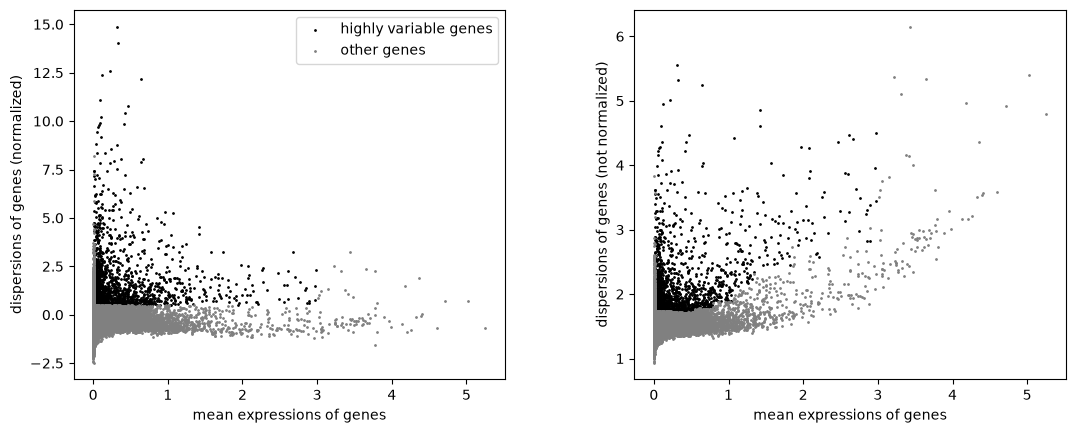

In [16]:
sc.pp.highly_variable_genes(adata_combined, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata_combined)

# a negative value indicates that a gene is less variable than expected relative to genes with comparable mean expression.

In [17]:
adata_combined_HVGs = adata_combined[:, adata_combined.var.highly_variable].copy() 

## Exploration

In [18]:
adata_combined_HVGs

AnnData object with n_obs × n_vars = 35179 × 1986
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'patient', 'tissue'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    layers: None (.X)

In [19]:
top_genes = (
    adata_combined.var
    .loc[adata_combined.var.highly_variable]
    .sort_values('dispersions_norm', ascending=False)
    .head(100)
    .index
    .tolist()
)

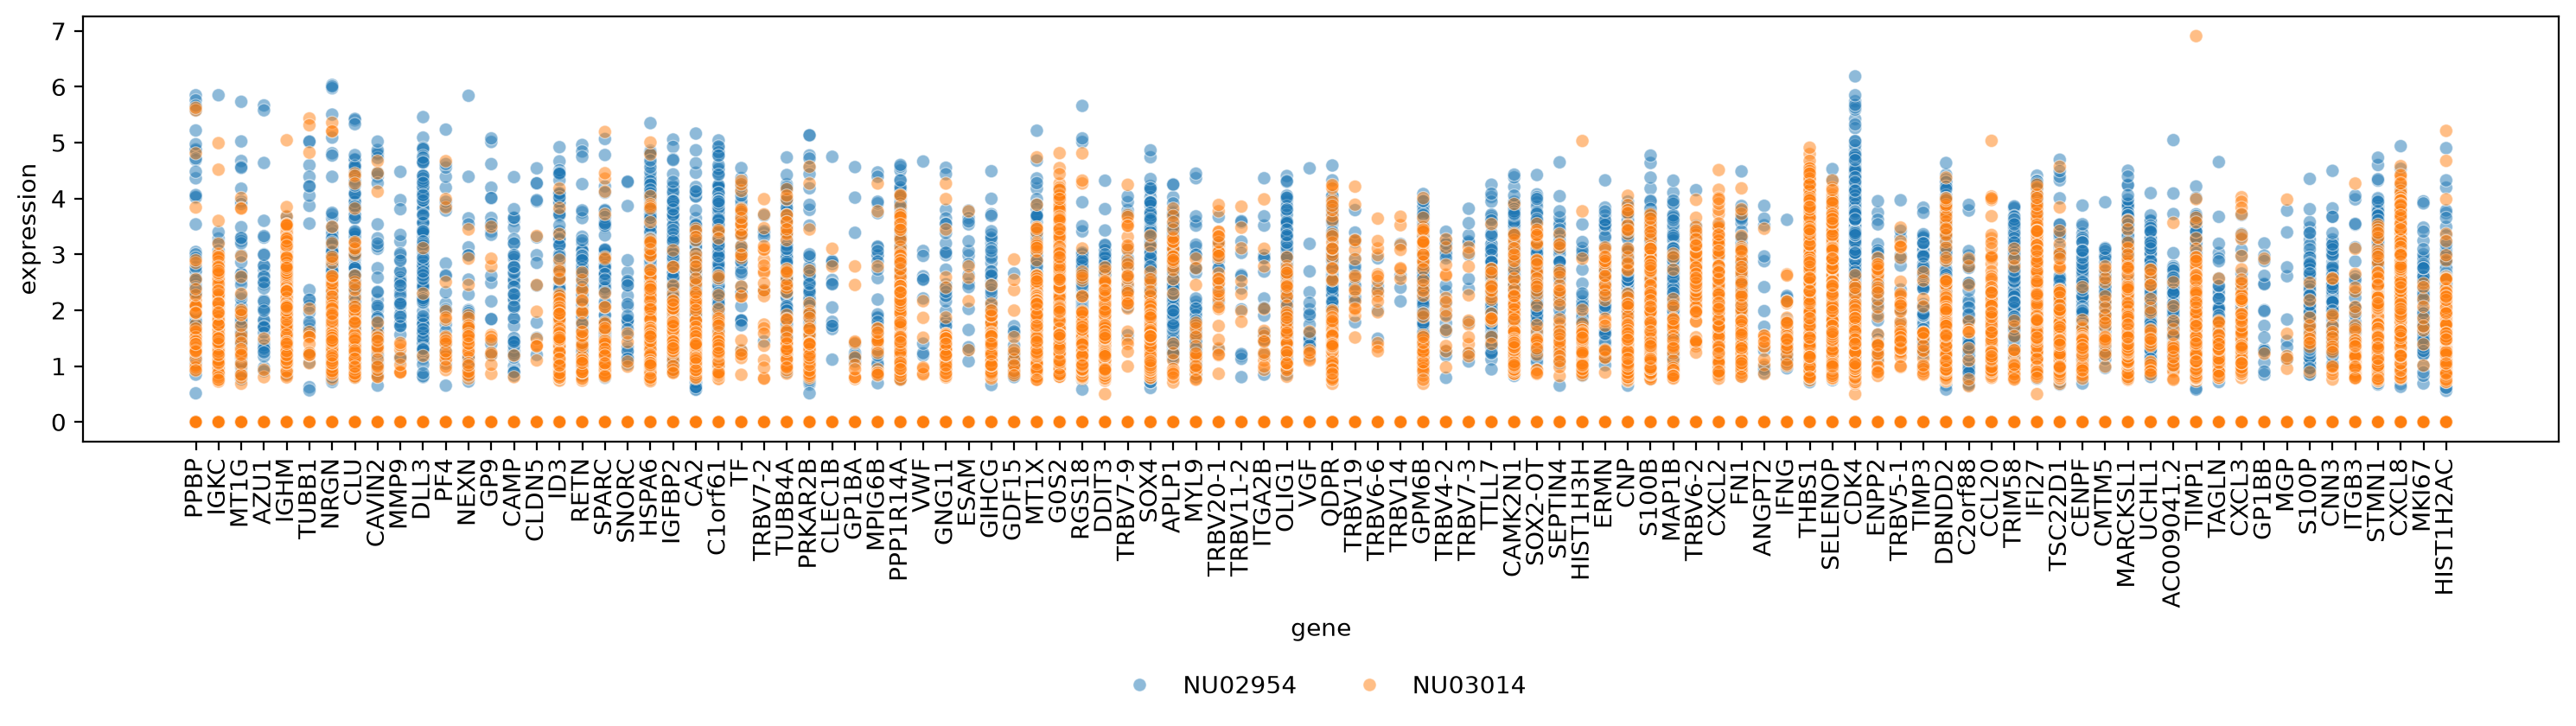

In [20]:
n = 2000  # Number of cells per patient–tissue combination

to_plot = adata_combined[:, top_genes].copy()

# Randomly sample n cells per patient and tissue (to facilitate visualization)
sampled_obs = (
    to_plot.obs
    .groupby(['patient', 'tissue'], observed=True, group_keys=False)
    .sample(n=n, random_state=42)
)

# Subset AnnData
to_plot = to_plot[sampled_obs.index, :].copy()

# Convert expression matrix to DataFrame
df = pd.DataFrame(
    to_plot.X.toarray(),
    columns=top_genes
)

# Add metadata
df['patient'] = to_plot.obs.patient.values
df['tissue'] = to_plot.obs.tissue.values

# Convert to long format
df_long = df.melt(
    id_vars=['patient', 'tissue'],
    var_name='gene',
    value_name='expression'
)

# Preserve HVG ranking
df_long['gene'] = pd.Categorical(
    df_long['gene'],
    categories=top_genes,
    ordered=True
)

# Plot

plt.figure(figsize=(15,5), dpi=200)

sns.scatterplot(
    data=df_long,
    x='gene',
    y='expression',
    hue='patient',
    # style='tissue',
    alpha=0.5,
    s=30,
    # legend=False,
)

plt.xticks(rotation=90)

# Move legend below the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()
plt.close('all')

The plot above shows that in general, gene expression is higher in NU02954 than in NU03014. This should eb taken into account when writing the results. 

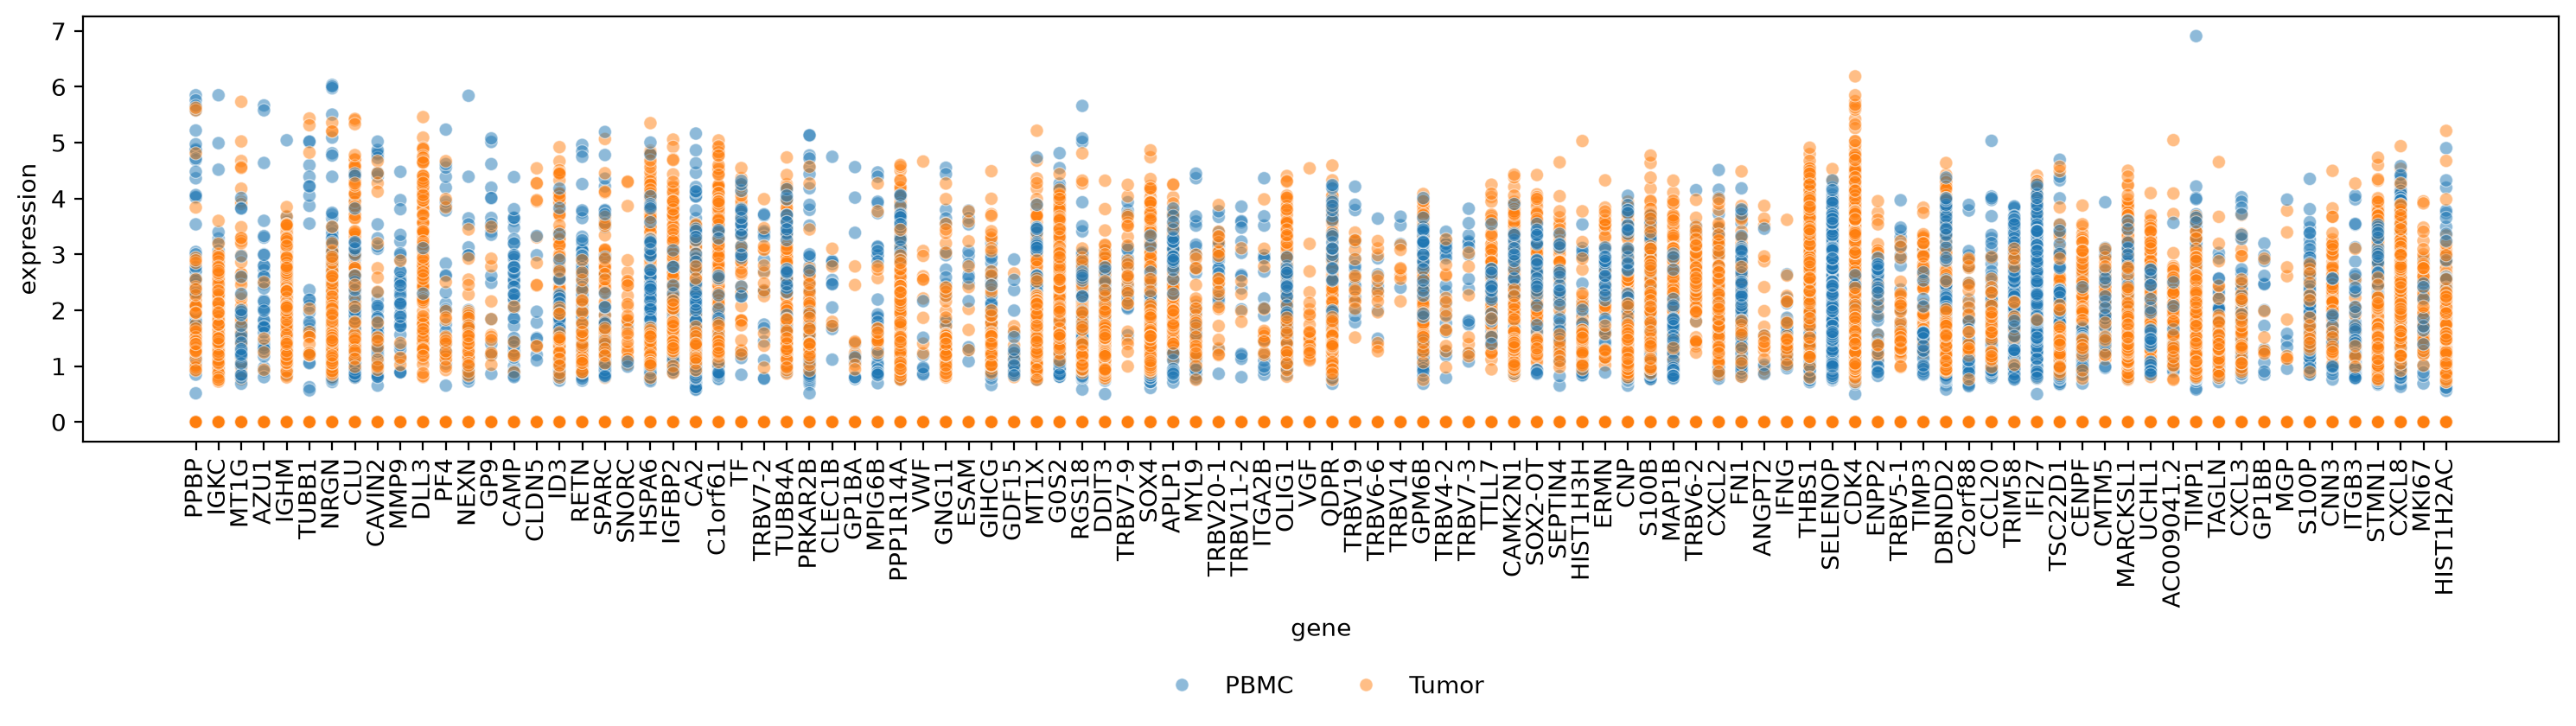

In [21]:
n = 2000  # Number of cells per patient–tissue combination

to_plot = adata_combined[:, top_genes].copy()

# Randomly sample n cells per patient and tissue (to facilitate visualization)
sampled_obs = (
    to_plot.obs
    .groupby(['patient', 'tissue'], observed=True, group_keys=False)
    .sample(n=n, random_state=42)
)

# Subset AnnData
to_plot = to_plot[sampled_obs.index, :].copy()

# Convert expression matrix to DataFrame
df = pd.DataFrame(
    to_plot.X.toarray(),
    columns=top_genes
)

# Add metadata
df['patient'] = to_plot.obs.patient.values
df['tissue'] = to_plot.obs.tissue.values

# Convert to long format
df_long = df.melt(
    id_vars=['patient', 'tissue'],
    var_name='gene',
    value_name='expression'
)

# Preserve HVG ranking
df_long['gene'] = pd.Categorical(
    df_long['gene'],
    categories=top_genes,
    ordered=True
)

# Plot

plt.figure(figsize=(15,5), dpi=200)

sns.scatterplot(
    data=df_long,
    x='gene',
    y='expression',
    hue='tissue',
    # style='tissue',
    alpha=0.5,
    s=30,
    # legend=False,
)

plt.xticks(rotation=90)

# Move legend below the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()
plt.close('all')

Right away, we can see that CDK4 is highly expressed in Tumor cells. This makes sense, as this gene plays a key role in tumorigenesis (Baker et al., 2012). 


Baker SJ, Reddy EP. CDK4: A Key Player in the Cell Cycle, Development, and Cancer: A Key Player in the Cell Cycle, Development, and Cancer. Genes & Cancer. 2012;3(11-12):658-669. doi:10.1177/1947601913478972
  

# Dimensionality reduction